## 🔹 Concept: Load Dataset
### 📌 What we are doing:
- Loading dataset
- Viewing first rows

In [1]:
import pandas as pd 
# Load dataset
df=pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")
# Show first 5 rows
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 🔹 Cell 2: Data Shape + Info

### 📌 What we are doing:
- Checking number of rows and columns
- Understanding data types
- Checking missing values

In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
df.info()
df.isnull().sum()

Shape: (506, 14)

Columns:
 Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

## 🔹 Cell 3: Separate Features and Target

### 📌 What we are doing:
- Separating input features (X)
- Separating target variable (y)

In [3]:
x=df.drop("medv",axis=1)
y=df["medv"]
print("x shape:",x.shape)
print("y shape:",y.shape)

x shape: (506, 13)
y shape: (506,)


## 🔹 Cell 4: Train-Test Split

### 📌 What we are doing:
- Splitting data into training and testing sets
- Training set → model learns patterns
- Testing set → evaluate performance

In [4]:
from sklearn.model_selection import train_test_split
# Split data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#check shapes 
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (404, 13)
x_test: (102, 13)
y_train: (404,)
y_test: (102,)


## 🔹 Cell 5: Linear Regression (Baseline Model)

### 📌 What we are doing:
- Training a Linear Regression model
- Making predictions on test data

In [5]:
from sklearn.linear_model import LinearRegression
#create model
model=LinearRegression()
#train model
model.fit(x_train,y_train)
#predictions 
y_pred=model.predict(x_test)

## 🔹 Cell 6: Model Evaluation

### 📌 What we are doing:
- Calculating error between actual and predicted values
- Using MSE, RMSE, and R² score

In [6]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse=",mse)
print("rmse=",rmse)
print("r2 score=",r2)

mse= 24.291119474973478
rmse= 4.928602182665332
r2 score= 0.6687594935356326


## 🔹 Cell 7: Actual vs Predicted Visualization

### 📌 What we are doing:
- Comparing actual values with predicted values
- Visualizing model performance

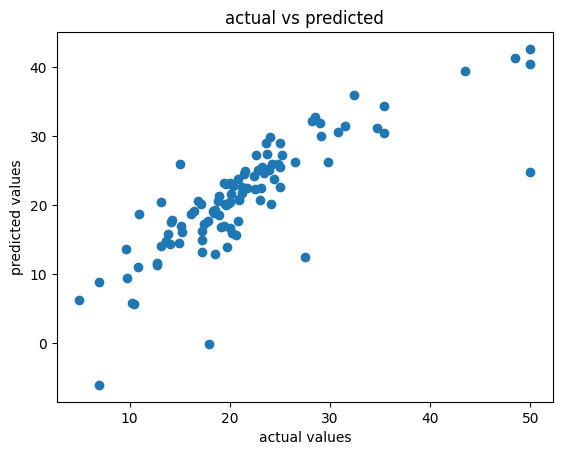

In [7]:
import matplotlib.pyplot as plt 
plt.scatter(y_test,y_pred)
plt.xlabel("actual values")
plt.ylabel("predicted values")
plt.title("actual vs predicted")
plt.show()

## 🔹 Cell 8: Residual Analysis

### 📌 What we are doing:
- Calculating residuals (errors)
- Visualizing how errors are distributed

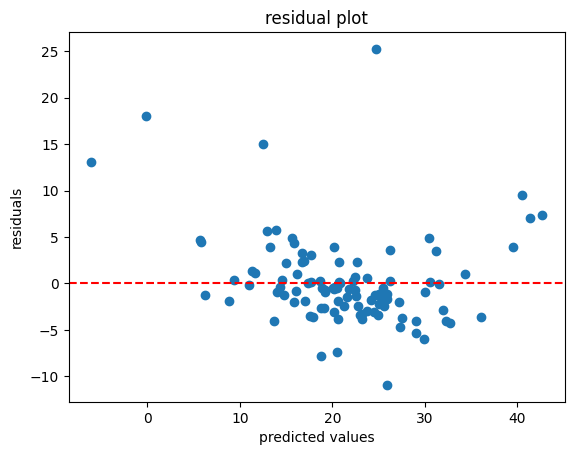

In [8]:
#Calculate residuals
residuals=y_test-y_pred
#plot residuals
import matplotlib.pyplot as plt 
plt.scatter(y_pred,residuals)
plt.xlabel("predicted values")
plt.ylabel("residuals")
plt.title("residual plot")
plt.axhline(y=0,color='r',linestyle='--')
plt.show()

## 🔹 Cell 9: Polynomial Regression

### 📌 What we are doing:
- Transforming features into polynomial form
- Training Linear Regression on new features
- Capturing non-linear relationships

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression 
# Create polynomial features (degree 2)
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
#train model
model_poly=LinearRegression()
model_poly.fit(x_train_poly,y_train)
#predictions
y_pred_poly=model_poly.predict(x_test_poly)

## 🔹 Cell 10: Evaluate Polynomial Model

### 📌 What we are doing:
- Evaluating Polynomial Regression
- Comparing with Linear Regression

In [10]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
mse_poly=mean_squared_error(y_test,y_pred_poly)
rmse_poly=np.sqrt(mse_poly)
r2_poly=r2_score(y_test,y_pred_poly)
print("Polynomial MSE:", mse_poly)
print("Polynomial RMSE:", rmse_poly)
print("Polynomial R2:", r2_poly)

Polynomial MSE: 14.257338166726361
Polynomial RMSE: 3.7758890564642336
Polynomial R2: 0.8055829448269859


## 🔹 Cell 11: Overfitting Check

### 📌 What we are doing:
- Checking model performance on training data
- Comparing with test performance
- Detecting overfitting

In [11]:
# Predictions on training data
y_train_pred_poly = model_poly.predict(x_train_poly)

# Training MSE
mse_train = mean_squared_error(y_train, y_train_pred_poly)

# Testing MSE (already calculated)
mse_test = mse_poly

print("Train MSE:", mse_train)
print("Test MSE:", mse_test)

Train MSE: 5.131464044082071
Test MSE: 14.257338166726361


## 🔹 Cell 12: Ridge Regression (Regularization)

### 📌 What we are doing:
- Applying Ridge Regression
- Controlling model complexity
- Reducing overfitting

In [12]:
from sklearn.linear_model import Ridge 
#create ridge model
ridge=Ridge(alpha=1.0)
ridge.fit(x_train_poly,y_train)
y_pred_ridge=ridge.predict(x_test_poly)
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
mse_ridge=mean_squared_error(y_test,y_pred_ridge)
rmse_ridge=np.sqrt(mse_ridge)
r2_ridge=r2_score(y_test,y_pred_ridge)
print("Ridge MSE:", mse_ridge)
print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge MSE: 14.142093755340687
Ridge RMSE: 3.7605975263700695
Ridge R2: 0.8071544498880807


## 🔹 Cell 13: Model Comparison

### 📌 What we are doing:
- Comparing performance of all models
- Choosing the best model

In [13]:
print("----- Model Comparison -----")
print("\nLinear Regression:")
print("MSE:", mse)
print("R2:", r2)

print("\nPolynomial Regression:")
print("MSE:", mse_poly)
print("R2:", r2_poly)

print("\nRidge Regression:")
print("MSE:", mse_ridge)
print("R2:", r2_ridge)

----- Model Comparison -----

Linear Regression:
MSE: 24.291119474973478
R2: 0.6687594935356326

Polynomial Regression:
MSE: 14.257338166726361
R2: 0.8055829448269859

Ridge Regression:
MSE: 14.142093755340687
R2: 0.8071544498880807


## 🔹 Cell 14: One Hot Encoding (OHE)

### 📌 What we are doing:
- Creating a categorical feature
- Converting it into numeric using One Hot Encoding

In [14]:
# Create a categorical feature based on 'rm' (number of rooms)
df['area_type'] = ['urban' if x > df['rm'].median() else 'rural' for x in df['rm']]
# Check
df[['rm', 'area_type']].head()

,rm,area_type
0,6.575,urban
1,6.421,urban
2,7.185,urban
3,6.998,urban
4,7.147,urban


In [15]:
df_encoded = pd.get_dummies(df, columns=['area_type'], drop_first=True)
df_encoded.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,area_type_urban
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,True
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,True
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,True
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,True
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,True


## 🔹 Cell 15: Recreate Features and Target

### 📌 What we are doing:
- Using encoded dataset
- Separating X and y again

In [16]:
# Features (X)
X = df_encoded.drop("medv", axis=1)

# Target (y)
y = df_encoded["medv"]

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (506, 14)
y shape: (506,)


## 🔹 Cell 16: Train-Test Split + Feature Scaling

### 📌 What we are doing:
- Splitting data again
- Applying StandardScaler
- Normalizing feature values

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print("X_train_scaled:", x_train_scaled.shape)
print("X_test_scaled:", x_test_scaled.shape)

X_train_scaled: (404, 13)
X_test_scaled: (102, 13)


## 🔹 Cell 17: Lasso Regression

### 📌 What we are doing:
- Applying Lasso Regression
- Reducing overfitting
- Performing feature selection

In [18]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.1)
lasso.fit(x_train_scaled,y_train)
y_pred_lasso=lasso.predict(x_test_scaled)
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
mse_lasso=mean_squared_error(y_test,y_pred_lasso)
rmse_lasso=np.sqrt(mse_lasso)
r2_lasso=r2_score(y_test,y_pred_lasso)
print("Lasso MSE:", mse_lasso)
print("Lasso RMSE:", rmse_lasso)
print("Lasso R2:", r2_lasso)

Lasso MSE: 25.656739367167678
Lasso RMSE: 5.065248203905479
Lasso R2: 0.6501375183238987


## 🔹 Cell 18: Decision Tree Regressor

### 📌 What we are doing:
- Using Decision Tree for regression
- Learning non-linear relationships automatically

In [22]:
from sklearn.tree import DecisionTreeRegressor
tree=DecisionTreeRegressor(random_state=42)
tree.fit(x_train,y_train)
y_pred_tree=tree.predict(x_test)
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np 
mse_tree=mean_squared_error(y_test,y_pred_tree)
rmse_tree=np.sqrt(mse_tree)
r2_tree=r2_score(y_test,y_pred_tree)
print("Tree MSE:", mse_tree)
print("Tree RMSE:", rmse_tree)
print("Tree R2:", r2_tree)
#overfitting check
y_train_pred_tree = tree.predict(x_train)
mse_train_tree = mean_squared_error(y_train, y_train_pred_tree)
print("Train MSE:", mse_train_tree)
print("Test MSE:", mse_tree)

Tree MSE: 10.416078431372549
Tree RMSE: 3.2273949915330395
Tree R2: 0.8579634380978161
Train MSE: 0.0
Test MSE: 10.416078431372549


## 🔹 Cell 19: Random Forest Regressor

### 📌 What we are doing:
- Using multiple decision trees
- Reducing overfitting
- Improving generalization

In [26]:
from sklearn.ensemble import RandomForestRegressor 
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np 
mse_rf=mean_squared_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mse_rf)
r2_rf=r2_score(y_test,y_pred_rf)
print("rf MSE:", mse_rf)
print("rf RMSE:", rmse_rf)
print("rf R2:", r2_rf)
#overfitting check
y_train_pred_rf = rf.predict(x_train)
mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
print("Train MSE:", mse_train_rf)
print("Test MSE:", mse_rf)

rf MSE: 7.901513892156864
rf RMSE: 2.8109631609391226
rf R2: 0.8922527442109116
Train MSE: 1.9783925024752465
Test MSE: 7.901513892156864


## 🔹 Final Cell: Model Comparison & Conclusion

### 📌 What we are doing:
- Comparing all models
- Selecting the best model
- Writing final conclusion

In [27]:
print("----- FINAL MODEL COMPARISON -----")

print("\nLinear Regression:")
print("MSE:", mse)
print("R2:", r2)

print("\nPolynomial Regression:")
print("MSE:", mse_poly)
print("R2:", r2_poly)

print("\nRidge Regression:")
print("MSE:", mse_ridge)
print("R2:", r2_ridge)

print("\nLasso Regression:")
print("MSE:", mse_lasso)
print("R2:", r2_lasso)

print("\nDecision Tree:")
print("MSE:", mse_tree)
print("R2:", r2_tree)

print("\nRandom Forest:")
print("MSE:", mse_rf)
print("R2:", r2_rf)

----- FINAL MODEL COMPARISON -----

Linear Regression:
MSE: 24.291119474973478
R2: 0.6687594935356326

Polynomial Regression:
MSE: 14.257338166726361
R2: 0.8055829448269859

Ridge Regression:
MSE: 14.142093755340687
R2: 0.8071544498880807

Lasso Regression:
MSE: 25.656739367167678
R2: 0.6501375183238987

Decision Tree:
MSE: 10.416078431372549
R2: 0.8579634380978161

Random Forest:
MSE: 7.901513892156864
R2: 0.8922527442109116


## 🔹 Cell 20: Feature Importance

### 📌 What we are doing:
- Extracting feature importance from Random Forest
- Understanding which features affect prediction most

In [28]:
import pandas as pd 
importance =rf.feature_importances_
feature_importance=pd.DataFrame({
    'Feature':x.columns,
    'Importance':importance
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
feature_importance

,Feature,Importance
5,rm,0.503845
12,lstat,0.309509
7,dis,0.060549
0,crim,0.038062
10,ptratio,0.016313
9,tax,0.015661
4,nox,0.015544
6,age,0.013840
11,b,0.012154
2,indus,0.007953


## 🔹 Cell 21: Feature Selection (Remove Weak Features)

### 📌 What we are doing:
- Removing low importance features
- Keeping only useful features

In [30]:
# Select top features (example: importance > 0.01)

selected_features = feature_importance[feature_importance['Importance'] > 0.01]['Feature']

# Create new dataset
x_selected = x[selected_features]

print("Selected features:")
print(selected_features)

print("\nNew shape:", x_selected.shape)

Selected features:
5          rm
12      lstat
7         dis
0        crim
10    ptratio
9         tax
4         nox
6         age
11          b
Name: Feature, dtype: object

New shape: (506, 9)


## 🔹 Cell 22: Retrain Model on Selected Features

### 📌 What we are doing:
- Training Random Forest on selected features
- Evaluating performance
- Comparing with previous model

In [31]:
# Split again with selected features
from sklearn.model_selection import train_test_split

x_train_sel, x_test_sel, y_train_sel, y_test_sel = train_test_split(
    x_selected, y, test_size=0.2, random_state=42
)

# Train Random Forest again
rf_selected = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selected.fit(x_train_sel, y_train_sel)

# Predict
y_pred_sel = rf_selected.predict(x_test_sel)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_sel = mean_squared_error(y_test_sel, y_pred_sel)
rmse_sel = np.sqrt(mse_sel)
r2_sel = r2_score(y_test_sel, y_pred_sel)

print("Selected Features MSE:", mse_sel)
print("Selected Features RMSE:", rmse_sel)
print("Selected Features R2:", r2_sel)

Selected Features MSE: 8.248318519607837
Selected Features RMSE: 2.8719886001876533
Selected Features R2: 0.88752361920869


## 🔹 Cell 23: Cross Validation

### 📌 What we are doing:
- Evaluating model on multiple splits
- Getting more reliable performance

In [32]:
from sklearn.model_selection import cross_val_score

# Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Cross validation (5-fold)
scores = cross_val_score(rf, x, y, scoring='neg_mean_squared_error', cv=5)

# Convert to positive MSE
mse_scores = -scores

print("MSE scores for each fold:", mse_scores)
print("Average MSE:", mse_scores.mean())

MSE scores for each fold: [ 7.86326927 12.96933489 20.69365651 46.54733788 18.7560397 ]
Average MSE: 21.365927652921755


## 🔹 Cell 24: Pipeline

### 📌 What we are doing:
- Combining preprocessing + model
- Creating clean and reusable ML pipeline

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
pipeline.fit(x_train, y_train)

# Predict
y_pred_pipe = pipeline.predict(x_test)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_pipe = mean_squared_error(y_test, y_pred_pipe)
rmse_pipe = np.sqrt(mse_pipe)
r2_pipe = r2_score(y_test, y_pred_pipe)

print("Pipeline MSE:", mse_pipe)
print("Pipeline RMSE:", rmse_pipe)
print("Pipeline R2:", r2_pipe)

Pipeline MSE: 7.912745333333333
Pipeline RMSE: 2.8129602438238144
Pipeline R2: 0.8920995891343227


## 🔹 Cell 25: Hyperparameter Tuning

### 📌 What we are doing:
- Tuning Random Forest parameters
- Finding best model configuration

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Model
rf = RandomForestRegressor(random_state=42)

# Parameters to try
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# Grid Search
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Train
grid.fit(x_train, y_train)

# Best model
best_rf = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

#evaluate best model
y_pred_best = best_rf.predict(x_test)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
print("Tuned MSE:", mse_best)
print("Tuned R2:", r2_best)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned MSE: 7.901513892156864
Tuned R2: 0.8922527442109116


## 🔹 Cell V1: Feature Distributions

### 📌 What we are doing:
- Visualizing distribution of features
- Understanding spread and skewness

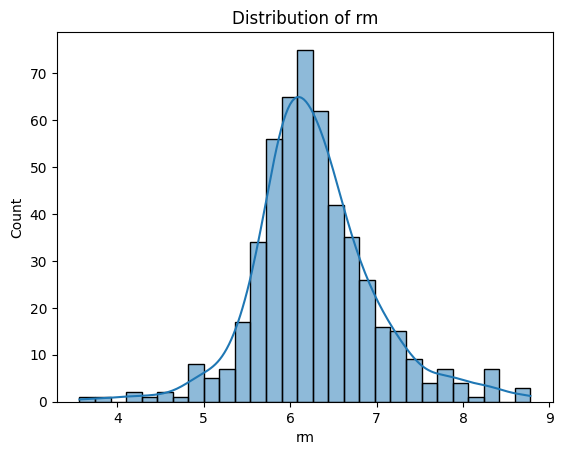

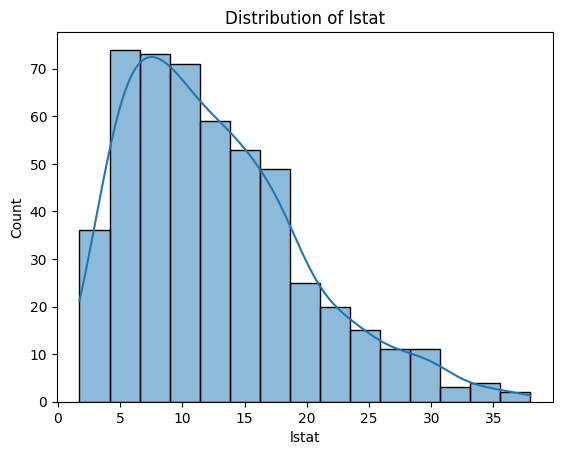

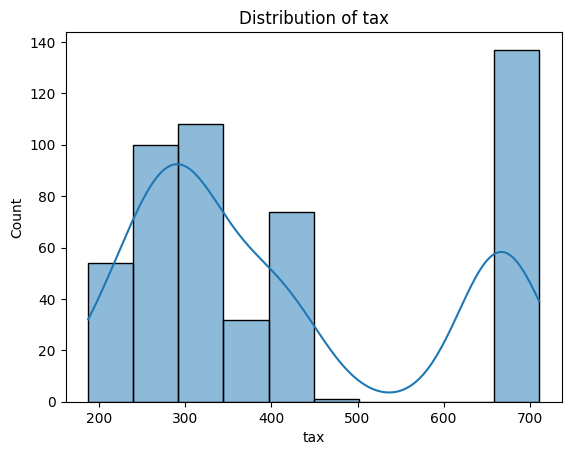

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of few important features
features = ['rm', 'lstat', 'tax']

for col in features:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

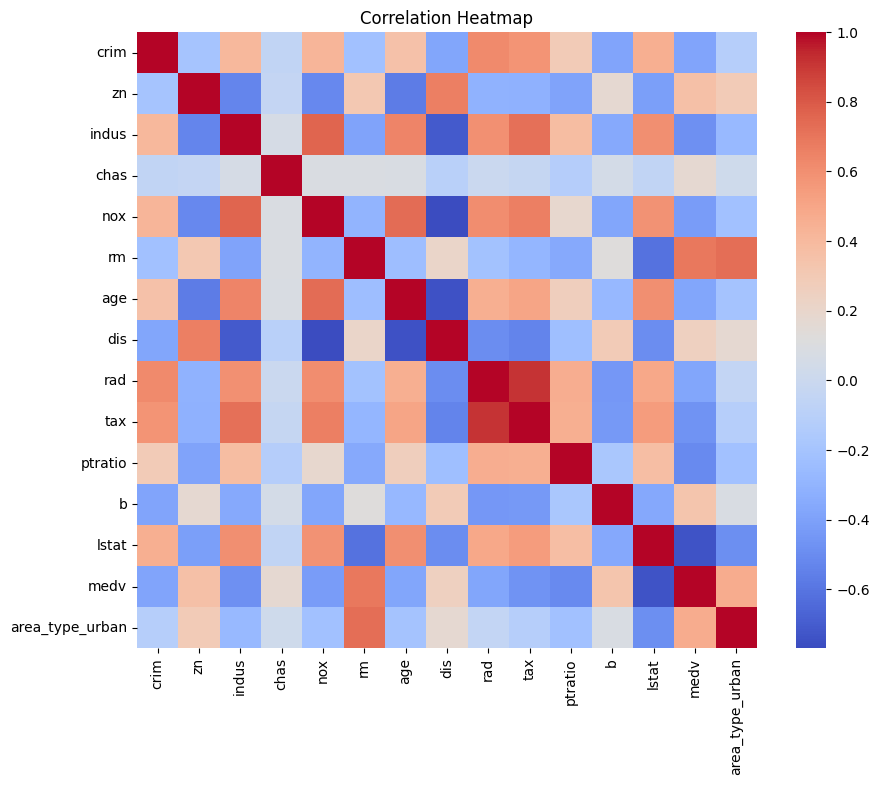

In [43]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

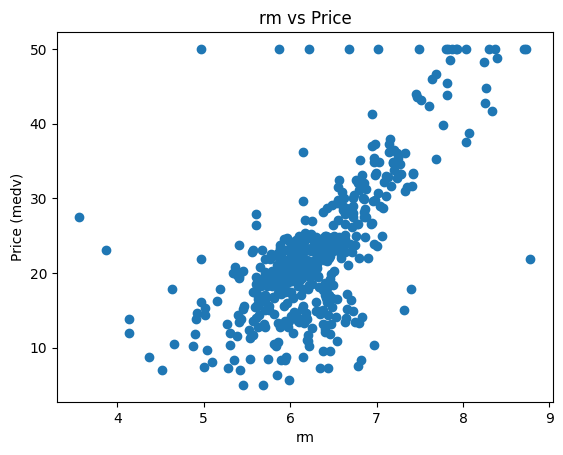

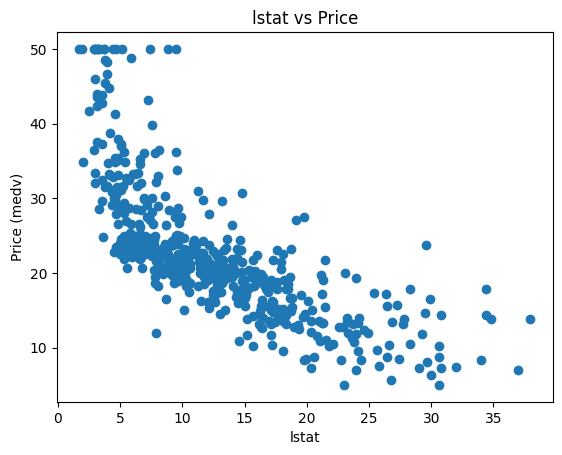

In [44]:
features = ['rm', 'lstat']

for col in features:
    plt.scatter(df[col], df['medv'])
    plt.xlabel(col)
    plt.ylabel("Price (medv)")
    plt.title(f"{col} vs Price")
    plt.show()

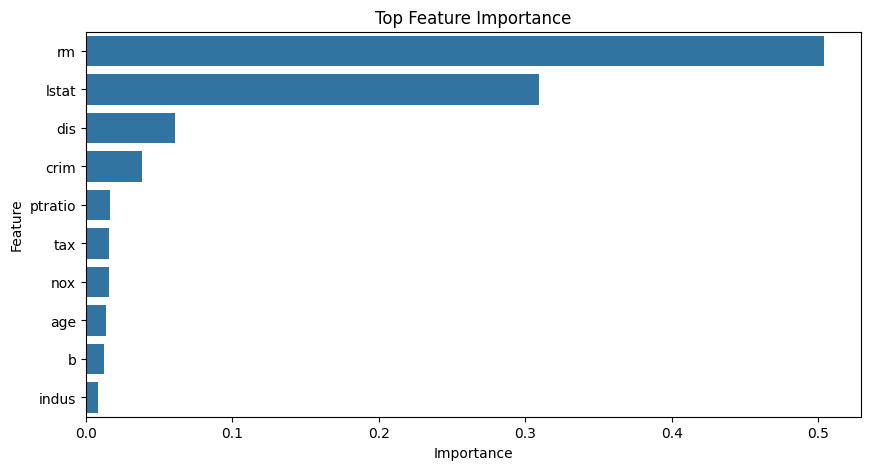

In [45]:
# Plot feature importance
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top Feature Importance")
plt.show()